# Model ablation

## ablate FM

In [ ]:
%%bash
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_no_otcfm.pt" \
            --no-otcfm \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## randomize graph

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

splits=(1 2 3)


# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_rgraph.pt" \
            --randomize-graph \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## both

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)
splits=(1 2 3)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        python ../scripts/gfm_run_all.py \
            --adata-path "${adata_paths[$i]}" \
            --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
            --output-dir "../data/gfm/${dataset}/split_${split}/" \
            --graph-dir "../data/" \
            --vae-name "vae.pt" \
            --model-name "gfm_rgraph_no_otcfm.pt" \
            --randomize-graph \
            --no-otcfm \
            --graph-type "go+pert+ppi" \
            --skip-vae-pretrain
    done
done

## Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from gfm.helpers import combine_results

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

In [ ]:
datasets = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
results = []

for dataset in datasets:
    results_dict = {
        'GFM': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (-FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_no_otcfm.csv" for s in [1, 2, 3]],
        'GFM (-graph)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph.csv" for s in [1, 2, 3]],
        'GFM (-graph-FM)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_no_otcfm.csv" for s in [1, 2, 3]],
        'Perturb train': [f"../data/pert_train/{dataset}/results_test_{s}.csv" for s in [1, 2, 3]]
    }
    res_dict = combine_results(
        results_dict, 
        baseline_model="Perturb train", 
        return_test_results=True,
        aggregate_by_split=True)
    aggr_res = res_dict['aggregated_results']
    aggr_res['dataset'] = dataset
    results.append(aggr_res)
    
results_all = pd.concat(results, ignore_index=True)

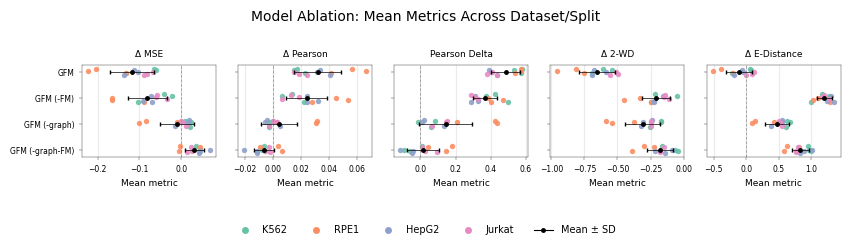

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D

summary = (
    results_all
    .groupby(['model'])
    .agg(
        mean_mse_mean=('mse_mean', 'mean'),
        mean_pearson_mean=('pearson_mean', 'mean'),
        mean_pearson_delta_mean=('pearson_delta_mean', 'mean'),
        mean_w2d_mean=('w2d_mean', 'mean'),
        mean_e_distance_mean=('e_distance_mean', 'mean'),
        sd_mse_mean=('mse_mean', 'std'),
        sd_pearson_mean=('pearson_mean', 'std'),
        sd_pearson_delta_mean=('pearson_delta_mean', 'std'),
        sd_w2d_mean=('w2d_mean', 'std'),
        sd_e_distance_mean=('e_distance_mean', 'std'),
    )
    .reset_index()
)

metrics = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']
metric_labels = {
    'mse': 'Δ MSE',
    'pearson': 'Δ Pearson',
    'pearson_delta': 'Pearson Delta',
    'w2d': 'Δ 2-WD',
    'e_distance': 'Δ E-Distance',
}

plot_df = results_all.copy()
plot_df['split'] = plot_df['split'].astype(str)

model_order = [
    m for m in [
        'GFM (-graph-FM)',
        'GFM (-graph)',
        'GFM (-FM)',
        'GFM',
    ] if m in plot_df['model'].unique()
 ]
if not model_order:
    model_order = sorted(plot_df['model'].unique())

dataset_order = [
    d for d in [
        'norman_single',
        'replogle_k562',
        'replogle_rpe1',
        'nadig_hepg2',
        'nadig_jurkat',
    ] if d in plot_df['dataset'].unique()
 ]
if not dataset_order:
    dataset_order = sorted(plot_df['dataset'].unique())

palette = dict(zip(dataset_order, sns.color_palette('Set2', len(dataset_order))))

fig, axes = plt.subplots(1, len(metrics), figsize=(1.7 * len(metrics), 2), sharey=True)
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    x_col = f'{metric}_mean'
    x_sum_col = f'mean_{metric}_mean'
    x_sd_col = f'sd_{metric}_mean'
    this_df = plot_df[['model', 'dataset', 'split', x_col]].dropna().copy()

    y_map = {model: idx for idx, model in enumerate(model_order)}
    this_df = this_df[this_df['model'].isin(model_order)]
    this_df[x_col] = pd.to_numeric(this_df[x_col], errors='coerce')
    this_df['y_base'] = this_df['model'].map(y_map).astype(float)

    rng = np.random.default_rng(42)
    this_df['y'] = this_df['y_base'] + rng.uniform(-0.17, 0.17, len(this_df))

    for _, row in this_df.iterrows():
        color = palette.get(row['dataset'], 'gray')

        ax.scatter(
            row[x_col],
            row['y'],
            color=color,
            marker='o',
            s=15,
            linewidth=0,
            alpha=0.9,
            zorder=2,
        )
    
    ax.errorbar(
        summary[x_sum_col],
        [y_map.get(model, np.nan) for model in summary['model']],
        xerr=summary[x_sd_col],
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=0.5,
        capsize=1.5,
        markersize=2.5,
        zorder=4,
    )

    ax.axvline(0, color='0.6', linestyle='--', linewidth=0.6)
    ax.grid(axis='x', alpha=0.25)
    ax.tick_params(axis='x')
    ax.set_title(metric_labels.get(metric, metric))
    ax.set_xlabel('Mean metric')

    ax.set_yticks(range(len(model_order)))

axes[0].set_yticklabels(model_order)
axes[0].tick_params(axis='y', labelleft=True, left=True)
for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

dataset_map = {
    'replogle_k562': 'K562',
    'replogle_rpe1': 'RPE1',
    'nadig_hepg2': 'HepG2',
    'nadig_jurkat': 'Jurkat',
}

dataset_handles = [
    Line2D([0], [0], marker='o', linestyle='', color=palette[d], markeredgewidth=0, markersize=5, label=dataset_map.get(d, d))
    for d in dataset_order
]
mean_handle = [
    Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=2.5, linewidth=0.8, label='Mean ± SD')
]

fig.legend(handles=dataset_handles + mean_handle, title=None, loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=len(dataset_handles) + 1, frameon=False, fontsize=7, title_fontsize=8)

fig.suptitle('Model Ablation: Mean Metrics Across Dataset/Split', y=1.03, fontsize=10)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.savefig("../data/final_plots/ablation_module_metrics_summary.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Graph ablation

In [ ]:
%%bash
# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)
splits=(1 2 3)

groups=("go" "ppi" "pert" "ppi+pert" "go+pert" "go+ppi")

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    for split in "${splits[@]}"; do
        for group in "${groups[@]}"; do
            python ../scripts/gfm_run_all.py \
                --adata-path "${adata_paths[$i]}" \
                --split-dict-path "../data/gears/${dataset}/splits/${dataset}_single_${split}_0.75.pkl" \
                --output-dir "../data/gfm/${dataset}/split_${split}/" \
                --graph-dir "../data/" \
                --vae-name "vae.pt" \
                --model-name "gfm_rgraph_${group}.pt" \
                --randomize-graph \
                --randomize-graph-type "${group}" \
                --graph-type "go+pert+ppi" \
                --skip-vae-pretrain
        done
    done
done

## Results

In [ ]:
datasets = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
results = []
test_results_list = []

for dataset in datasets:
    results_dict = {
        'GFM (GO+PPI+Pert)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_go+gwps+ppi_gat.csv" for s in [1, 2, 3]],
        'GFM (PPI+Pert)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_go.csv" for s in [1, 2, 3]],
        'GFM (GO+Pert)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_ppi.csv" for s in [1, 2, 3]],
        'GFM (GO+PPI+)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_pert.csv" for s in [1, 2, 3]],
        'GFM (GO)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_ppi+pert.csv" for s in [1, 2, 3]],
        'GFM (PPI)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_go+pert.csv" for s in [1, 2, 3]],
        'GFM (Pert)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph_go+ppi.csv" for s in [1, 2, 3]],
        'GFM (rand. all graphs)': [f"../data/gfm/{dataset}/split_{s}/results_test_gfm_rgraph.csv" for s in [1, 2, 3]],
        'Perturb train': [f"../data/pert_train/{dataset}/results_test_{s}.csv" for s in [1, 2, 3]]
    }
    res_dict = combine_results(
        results_dict, 
        baseline_model="Perturb train", 
        return_test_results=True,
        aggregate_by_split=True,
        reference_model='GFM (GO+PPI+Pert)')
    aggr_res = res_dict['aggregated_results']
    aggr_res['dataset'] = dataset
    results.append(aggr_res)

    test_results = res_dict['test_results']
    test_results['dataset'] = dataset
    test_results_list.append(test_results)
    
results_all = pd.concat(results, ignore_index=True)
test_results_all = pd.concat(test_results_list, ignore_index=True)

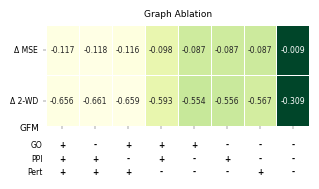

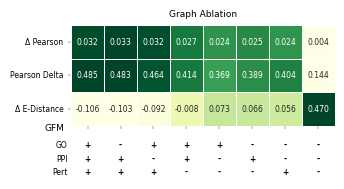

In [ ]:

# Reusable heatmap function for graph ablation summaries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ablation_heatmap(
    results_all,
    metrics,
    metric_labels=None,
    model_order=None,
    figsize_scale=0.6,
    cmap='YlGn',
    title='Graph Ablation',
    save_path=None,
    show_bottom_design=True,
    bottom_title_x=-0.1,
):
    if metric_labels is None:
        metric_labels = {
            'mse': 'Δ MSE',
            'pearson': 'Δ Pearson',
            'pearson_delta': 'Pearson Delta',
            'w2d': 'Δ 2-WD',
            'e_distance': 'Δ E-Distance',
        }

    if model_order is None:
        model_order = [
            'GFM (GO+PPI+Pert)',
            'GFM (PPI+Pert)',
            'GFM (GO+Pert)',
            'GFM (GO+PPI+)',
            'GFM (GO)',
            'GFM (PPI)',
            'GFM (Pert)',
            'GFM (rand. all graphs)',
        ]
    model_order = [m for m in model_order if m in results_all['model'].unique()]
    if not model_order:
        model_order = sorted(results_all['model'].unique())

    mean_by_model = (
        results_all
        .groupby('model')[[f'{m}_mean' for m in metrics]]
        .mean()
        .reindex(model_order)
    )

    # Raw values are used for annotations; color values are row-normalized
    heatmap_df = mean_by_model.T.copy()
    heatmap_df.index = [metric_labels.get(m, m) for m in metrics]

    row_min = heatmap_df.min(axis=1)
    row_max = heatmap_df.max(axis=1)
    row_range = (row_max - row_min).replace(0, np.nan)
    heatmap_color = heatmap_df.sub(row_min, axis=0).div(row_range, axis=0).fillna(0.5)

    components = ['GO', 'PPI', 'Pert']
    component_map = {
        'GFM (GO+PPI+Pert)': {'GO': '+', 'PPI': '+', 'Pert': '+'},
        'GFM (PPI+Pert)': {'GO': '-', 'PPI': '+', 'Pert': '+'},
        'GFM (GO+Pert)': {'GO': '+', 'PPI': '-', 'Pert': '+'},
        'GFM (GO+PPI+)': {'GO': '+', 'PPI': '+', 'Pert': '-'},
        'GFM (GO)': {'GO': '+', 'PPI': '-', 'Pert': '-'},
        'GFM (PPI)': {'GO': '-', 'PPI': '+', 'Pert': '-'},
        'GFM (Pert)': {'GO': '-', 'PPI': '-', 'Pert': '+'},
        'GFM (rand. all graphs)': {'GO': '-', 'PPI': '-', 'Pert': '-'},
    }

    design_text = pd.DataFrame(index=components, columns=heatmap_df.columns)
    for col in design_text.columns:
        comp_cfg = component_map.get(col, {})
        for comp in components:
            design_text.loc[comp, col] = comp_cfg.get(comp, '-')

    if show_bottom_design:
        fig = plt.figure(figsize=(3.4, 2.0))
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.0, 1.2], hspace=0.18)
        ax_top = fig.add_subplot(gs[0])
        ax_bottom = fig.add_subplot(gs[1])
    else:
        fig, ax_top = plt.subplots(1, 1, figsize=(3.4, 1.6))
        ax_bottom = None

    sns.heatmap(
        heatmap_color,
        ax=ax_top,
        cmap=cmap,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        cbar=False,
        annot=heatmap_df.values,
        fmt='.3f',
        annot_kws={'fontsize': 5.5},
    )
    ax_top.set_xlabel('')
    ax_top.set_xticklabels([])
    ax_top.set_yticklabels(ax_top.get_yticklabels(), rotation=0)
    ax_top.set_title(title, fontsize=6.5)

    if show_bottom_design and ax_bottom is not None:
        n_rows, n_cols = design_text.shape
        ax_bottom.set_xlim(0, n_cols)
        ax_bottom.set_ylim(0, n_rows)
        ax_bottom.invert_yaxis()

        for i, row_name in enumerate(design_text.index):
            ax_bottom.text(
                -0.1,
                i + 0.5,
                row_name,
                ha='right',
                va='center',
                fontsize=5.5,
            )
            for j, col_name in enumerate(design_text.columns):
                ax_bottom.text(
                    j + 0.5,
                    i + 0.5,
                    design_text.loc[row_name, col_name],
                    ha='center',
                    va='center',
                    fontsize=5.5,
                    fontweight='bold',
                    color='black',
                )

        ax_bottom.set_xticks([])
        ax_bottom.set_yticks([])
        ax_bottom.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        ax_bottom.set_ylabel('')
        # Move title further left so it aligns with GO/PPI/Pert label block.
        ax_bottom.set_title('GFM', fontsize=6.5, loc='left', x=bottom_title_x)

        for spine in ax_bottom.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 1) MSE and W2D
plot_ablation_heatmap(
    results_all=results_all,
    metrics=['mse', 'w2d'],
    save_path='../data/final_plots/ablation_graph_metrics_heatmap_mse_w2d.pdf',
)

# 2) Pearson-based and E-distance
plot_ablation_heatmap(
    results_all=results_all,
    metrics=['pearson', 'pearson_delta', 'e_distance'],
    save_path='../data/final_plots/ablation_graph_metrics_heatmap_corr_edist.pdf',
)
